In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

## this is analysis for Isaac ran on a cleaned dataset


In [3]:
df=pd.read_csv('data/30k.csv')
df.head()

,#,Date,Agent,Map,w,l,result,Rank,Queue Type,K,D,A,ADR,HS%,KAST,FK,FD,MK's,Link:
0,1.0,5/19/2023,Raze,Lotus,15.0,13.0,Win,Silver 1,1.0,35.0,16.0,6.0,206.6,6%,82%,6.0,2.0,7.0,Raze 35 - Lotus
1,2.0,8/26/2023,Jett,Pearl,15.0,17.0,Loss,Gold 2,5.0,31.0,20.0,1.0,167.2,16%,72%,3.0,1.0,2.0,Jett 31 - Pearl
2,3.0,8/30/2023,Astra,Lotus,19.0,17.0,Win,Gold 2,3.0,36.0,23.0,7.0,167.4,11%,78%,6.0,0.0,3.0,Astra 36 - Lotus
3,4.0,11/28/2023,Harbor,Ascent,13.0,8.0,Win,Plat 2,5.0,31.0,9.0,5.0,225.2,16%,86%,2.0,0.0,3.0,Harbor 31 - Ascent
4,5.0,11/28/2023,Jett,Bind,13.0,11.0,Win,Plat 2,5.0,32.0,13.0,2.0,206.4,9%,88%,6.0,1.0,4.0,Jett 32 - Bind


In [4]:
df.describe()

,#,w,l,Queue Type,K,D,A,ADR,FK,FD,MK's
count,30.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,15.500000,14.038462,12.692308,4.384615,31.615385,17.423077,6.653846,214.469231,4.307692,1.692308,3.615385
std,8.803408,2.537412,3.781737,1.358732,2.155494,5.756201,3.815152,35.986617,2.240879,1.715091,1.416388
min,1.000000,9.000000,5.000000,1.000000,30.000000,9.000000,1.000000,167.200000,0.000000,0.000000,1.000000
25%,8.250000,13.000000,11.000000,5.000000,30.000000,13.000000,4.000000,190.750000,3.000000,1.000000,3.000000
50%,15.500000,13.000000,13.000000,5.000000,31.000000,17.000000,6.000000,208.750000,5.000000,1.000000,3.500000
75%,22.750000,15.000000,15.000000,5.000000,32.000000,22.000000,8.000000,230.150000,6.000000,2.000000,5.000000
max,30.000000,23.000000,21.000000,5.000000,38.000000,32.000000,16.000000,309.900000,10.000000,8.000000,7.000000


In [5]:
df.dtypes



#             float64
Date              str
Agent             str
Map               str
w             float64
l             float64
result            str
Rank              str
Queue Type    float64
K             float64
D             float64
A             float64
ADR           float64
HS%               str
KAST              str
FK            float64
FD            float64
MK's          float64
Link:             str
dtype: object

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].describe()



count                            26
mean     2024-05-06 12:55:23.076923
min             2023-01-11 00:00:00
25%             2024-02-17 12:00:00
50%             2024-08-06 12:00:00
75%             2024-09-08 06:00:00
max             2025-01-13 00:00:00
Name: Date, dtype: object

In [7]:
#convert strings to categories
df['Agent'] = df['Agent'].astype('category') 
cat_cols = ['Agent', 'Map', 'result', 'Rank']
df[cat_cols]= df[cat_cols].astype('category')
df.dtypes

#                    float64
Date          datetime64[us]
Agent               category
Map                 category
w                    float64
l                    float64
result              category
Rank                category
Queue Type           float64
K                    float64
D                    float64
A                    float64
ADR                  float64
HS%                      str
KAST                     str
FK                   float64
FD                   float64
MK's                 float64
Link:                    str
dtype: object

In [8]:
df.head()

,#,Date,Agent,Map,w,l,result,Rank,Queue Type,K,D,A,ADR,HS%,KAST,FK,FD,MK's,Link:
0,1.0,2023-05-19,Raze,Lotus,15.0,13.0,Win,Silver 1,1.0,35.0,16.0,6.0,206.6,6%,82%,6.0,2.0,7.0,Raze 35 - Lotus
1,2.0,2023-08-26,Jett,Pearl,15.0,17.0,Loss,Gold 2,5.0,31.0,20.0,1.0,167.2,16%,72%,3.0,1.0,2.0,Jett 31 - Pearl
2,3.0,2023-08-30,Astra,Lotus,19.0,17.0,Win,Gold 2,3.0,36.0,23.0,7.0,167.4,11%,78%,6.0,0.0,3.0,Astra 36 - Lotus
3,4.0,2023-11-28,Harbor,Ascent,13.0,8.0,Win,Plat 2,5.0,31.0,9.0,5.0,225.2,16%,86%,2.0,0.0,3.0,Harbor 31 - Ascent
4,5.0,2023-11-28,Jett,Bind,13.0,11.0,Win,Plat 2,5.0,32.0,13.0,2.0,206.4,9%,88%,6.0,1.0,4.0,Jett 32 - Bind


In [9]:
df['KAST']= df ['KAST'].str.rstrip('%').astype(float)/100
df['HS%']= df ['HS%'].str.rstrip('%').astype(float)/100

df[['HS','KAST']].dtypes

KeyError: "['HS'] not in index"

In [ ]:
df[['HS%', 'KAST']].dtypes

HS%     float64
KAST    float64
dtype: object

In [ ]:
df.head()


,#,Date,Agent,Map,w,l,result,Rank,Queue Type,K,D,A,ADR,HS%,KAST,FK,FD,MK's,Link:
0,1.0,2023-05-19,Raze,Lotus,15.0,13.0,Win,Silver 1,1.0,35.0,16.0,6.0,206.6,0.06,0.82,6.0,2.0,7.0,Raze 35 - Lotus
1,2.0,2023-08-26,Jett,Pearl,15.0,17.0,Loss,Gold 2,5.0,31.0,20.0,1.0,167.2,0.16,0.72,3.0,1.0,2.0,Jett 31 - Pearl
2,3.0,2023-08-30,Astra,Lotus,19.0,17.0,Win,Gold 2,3.0,36.0,23.0,7.0,167.4,0.11,0.78,6.0,0.0,3.0,Astra 36 - Lotus
3,4.0,2023-11-28,Harbor,Ascent,13.0,8.0,Win,Plat 2,5.0,31.0,9.0,5.0,225.2,0.16,0.86,2.0,0.0,3.0,Harbor 31 - Ascent
4,5.0,2023-11-28,Jett,Bind,13.0,11.0,Win,Plat 2,5.0,32.0,13.0,2.0,206.4,0.09,0.88,6.0,1.0,4.0,Jett 32 - Bind


In [ ]:
df.isnull().sum()

#             2
Date          6
Agent         6
Map           6
w             6
l             6
result        6
Rank          6
Queue Type    6
K             6
D             6
A             6
ADR           6
HS%           6
KAST          6
FK            6
FD            6
MK's          6
Link:         6
dtype: int64

In [ ]:
df = df.dropna()
df.isnull().sum()

#             0
Date          0
Agent         0
Map           0
w             0
l             0
result        0
Rank          0
Queue Type    0
K             0
D             0
A             0
ADR           0
HS%           0
KAST          0
FK            0
FD            0
MK's          0
Link:         0
dtype: int64

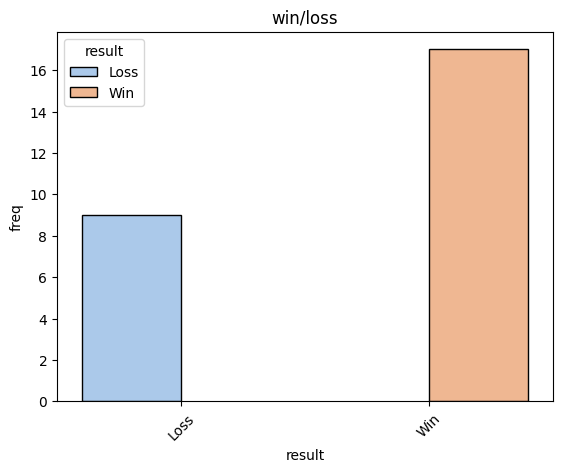

In [ ]:
ax = sns.countplot(data=df, x='result', palette= 'pastel', edgecolor='black', hue='result', legend=True)

ax.set_title('win/loss')
ax.set_xlabel('result')
ax.set_ylabel('freq')
ax.tick_params(axis='x', rotation = 45)

<Axes: xlabel='Map', ylabel='w'>

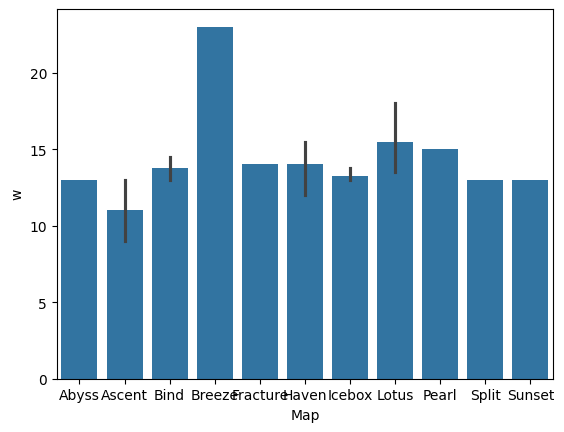

In [ ]:
# here lets make a bar chart of map performance. 
sns.barplot(data=df, x='Map', y='w')

<Axes: xlabel='Map', ylabel='ADR'>

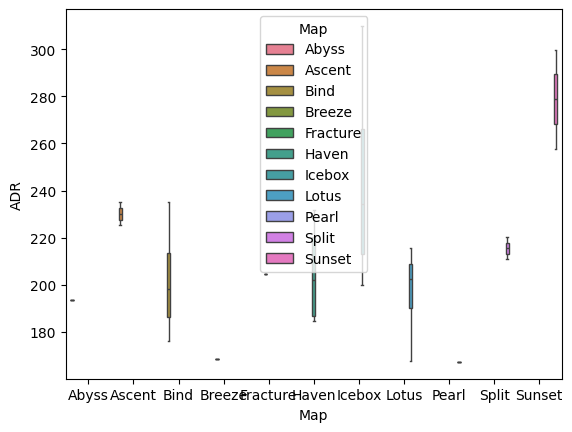

In [ ]:
sns.boxplot(data=df, x='Map', y='ADR', hue='Map')

In [ ]:
df.drop(columns=['Link:'], inplace=True)
df.head()


,#,Date,Agent,Map,w,l,result,Rank,Queue Type,K,D,A,ADR,HS%,KAST,FK,FD,MK's
0,1.0,2023-05-19,Raze,Lotus,15.0,13.0,Win,Silver 1,1.0,35.0,16.0,6.0,206.6,0.06,0.82,6.0,2.0,7.0
1,2.0,2023-08-26,Jett,Pearl,15.0,17.0,Loss,Gold 2,5.0,31.0,20.0,1.0,167.2,0.16,0.72,3.0,1.0,2.0
2,3.0,2023-08-30,Astra,Lotus,19.0,17.0,Win,Gold 2,3.0,36.0,23.0,7.0,167.4,0.11,0.78,6.0,0.0,3.0
3,4.0,2023-11-28,Harbor,Ascent,13.0,8.0,Win,Plat 2,5.0,31.0,9.0,5.0,225.2,0.16,0.86,2.0,0.0,3.0
4,5.0,2023-11-28,Jett,Bind,13.0,11.0,Win,Plat 2,5.0,32.0,13.0,2.0,206.4,0.09,0.88,6.0,1.0,4.0


In [16]:
df.dtypes


#                    float64
Date          datetime64[us]
Agent               category
Map                 category
w                    float64
l                    float64
result              category
Rank                category
Queue Type           float64
K                    float64
D                    float64
A                    float64
ADR                  float64
HS%                  float64
KAST                 float64
FK                   float64
FD                   float64
MK's                 float64
dtype: object

In [20]:
df[['result','Queue Type']]

,result,Queue Type
0,Win,1.0
1,Loss,5.0
2,Win,3.0
3,Win,5.0
4,Win,5.0
5,Win,5.0
6,Loss,3.0
7,Win,1.0
8,Win,1.0
9,Win,5.0


<Axes: xlabel='Queue Type', ylabel='count'>

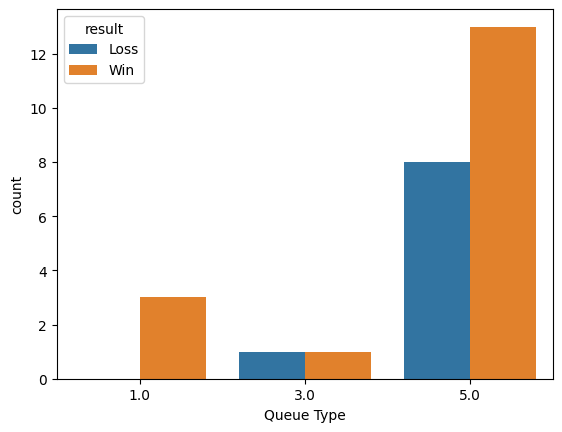

In [32]:
sns.countplot(data=df, hue='result', x='Queue Type')
